# AirSense Cameroon — Model Training

**Hackathon:** IndabaX Cameroon 2026  
**Theme:** *L'IA au service de la résilience climatique et sanitaire au Cameroun*  
**Author:** AirSense  
**Date:** March 2026

---

## Table of Contents

1. [Step 1 — Setup and Load](#s1)
2. [Step 2 — Feature Preparation](#s2)
3. [Step 3 — Train / Validation / Test Split](#s3)
4. [Step 4 — Baseline Model](#s4)
5. [Step 5 — XGBoost Single-Output: PM2.5](#s5)
6. [Step 6 — XGBoost Multi-Output: All 8 Compounds](#s6)
7. [Step 7 — REINFORCE RL Agent: City-Specific Alert Thresholds](#s7)
8. [Step 8 — Model Evaluation and SHAP Analysis](#s8)
9. [Step 9 — Regional Error Analysis](#s9)
10. [Step 10 — Save Models and Results](#s10)

---

### Modelling Strategy

The competition asks for three things: **Predict** air pollution indicators,
**Identify** climate factors by region, and **Support Decision Making**.
Our modelling pipeline addresses all three:

| Component | Addresses | Method |
|---|---|---|
| XGBoost PM2.5 | Predict | Gradient boosting on weather features |
| XGBoost multi-output | Predict | 8 compounds jointly |
| SHAP analysis | Identify | Feature importance by region |
| REINFORCE RL agent | Support Decision Making | Learns city-specific alert thresholds |

**Key decisions from EDA:**
- Log-transform PM2.5, dust, PM10 and AOD targets (skewness > 2)
- Drop `pm25_is_real` and all `_is_real` flags (all 1s, no information)
- `weather_code` treated as categorical
- Region encoded as categorical
- Split by time not randomly (avoid data leakage across dates)


<a id='s1'></a>
## Step 1 — Setup and Load


In [2]:
import subprocess, sys
required = {'xgboost':'xgboost','shap':'shap','sklearn':'scikit-learn'}
for module, package in required.items():
    try: __import__(module)
    except ImportError:
        print(f'Installing {package}...')
        subprocess.check_call([sys.executable,'-m','pip','install',package,'-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import warnings, os, json, pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

NAVY  = '#0D1B3E'; TEAL = '#0F7B8A'; AMBER = '#F59E0B'
GREEN = '#22C55E'; RED  = '#EF4444'; ORANGE = '#F97316'
REGION_COLORS = {
    'Far North':RED,'North':ORANGE,'Adamawa':AMBER,'West':'#8B5CF6',
    'North West':'#EC4899','Littoral':TEAL,'Centre':'#06B6D4',
    'East':'#84CC16','South West':GREEN,'South':'#10B981',
}
plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,
})

data_dir    = os.path.abspath(os.path.join(os.getcwd(),'..','data'))
outputs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','outputs'))
models_dir  = os.path.abspath(os.path.join(os.getcwd(),'..','models'))
os.makedirs(outputs_dir, exist_ok=True)
os.makedirs(models_dir,  exist_ok=True)

df = pd.read_csv(os.path.join(data_dir,'cameroon_final.csv'), parse_dates=['date'])
print(f'✓ Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'  Period : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'  Nulls  : {df.isnull().sum().sum():,}')
print(f'\nxgboost version : {xgb.__version__}')
print(f'shap version    : {shap.__version__}')

COMPOUNDS = ['pm2_5','pm10','dust','co','no2','o3','so2','aod']
TARGETS   = [f'{c}_target' for c in COMPOUNDS]
LOG_TARGETS = ['pm2_5_target','pm10_target','dust_target','aod_target']


c:\Users\SHALOM\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Dataset loaded: 87,240 rows x 73 columns
  Period : 2020-01-01 to 2025-12-20
  Nulls  : 37,880

xgboost version : 3.2.0
shap version    : 0.49.1


<a id='s2'></a>
## Step 2 — Feature Preparation

**Decisions from EDA:**
- Log-transform PM2.5, PM10, dust and AOD targets (right-skewed, skewness > 2)
- Drop all `_is_real` flags — all 1s, carry no information
- Drop `pm25_starter_proxy` — only needed for comparison, not for training
- Encode `region` and `weather_code` as integers for XGBoost
- Keep `city` encoded — city-level fixed effects are meaningful
- `latitude` and `longitude` already numeric — keep as-is

**Why log-transform?**  
PM2.5 skewness of 2.37 means extreme Harmattan values would dominate the
loss function, causing the model to over-fit to northern extreme events
at the expense of accuracy across the majority of city-days.
Log-transform compresses the right tail and stabilises variance.
Predictions are inverse-transformed back to μg/m³ for evaluation.


In [3]:
# ── Drop non-feature columns ──────────────────────────────────────────────────
drop_cols = [
    # is_real flags — all 1s
    'pm25_is_real','pm10_is_real','dust_is_real','co_is_real',
    'no2_is_real','so2_is_real','o3_is_real','aod_is_real',
    # proxy comparison
    'pm25_starter_proxy',
    # raw compound columns (targets are the _target versions)
    'pm2_5','pm10','dust','co','no2','o3','so2','aod','eu_aqi',
    # engineered ratio (derived from targets)
    'pm_ratio',
]
# Only drop columns that actually exist
drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f'✓ Dropped {len(drop_cols)} non-feature columns')

# ── Log-transform skewed targets ──────────────────────────────────────────────
for col in LOG_TARGETS:
    log_col = f'log_{col}'
    df[log_col] = np.log1p(df[col])
print(f'✓ Log-transformed: {LOG_TARGETS}')

# ── Encode categorical columns ────────────────────────────────────────────────
le_region = LabelEncoder()
le_city   = LabelEncoder()
df['region_enc']       = le_region.fit_transform(df['region'])
df['city_enc']         = le_city.fit_transform(df['city'])
df['weather_code_cat'] = df['weather_code'].astype('category').cat.codes
print(f'✓ Encoded: region ({df["region_enc"].nunique()} classes), '
      f'city ({df["city_enc"].nunique()} classes), '
      f'weather_code ({df["weather_code_cat"].nunique()} classes)')

# ── Define feature set ────────────────────────────────────────────────────────
FEATURES = [
    # Geography
    'latitude','longitude','region_enc','city_enc',
    # Temporal
    'month','day_of_year','year','month_sin','month_cos','doy_sin','doy_cos',
    # Official weather
    'temp_max','temp_min','temp_mean','apparent_temp_mean',
    'precipitation','precipitation_hours',
    'wind_speed','wind_direction','wind_u','wind_v',
    'solar_radiation','evapotranspiration','daylight_duration',
    'weather_code_cat',
    # Fetched weather
    'humidity','dew_point','surface_pressure','cloud_cover',
    'wind_100m','soil_moisture','soil_temp','wet_bulb_temp','vpd','vpd_max',
    # Engineered
    'temp_range','sunshine_ratio',
    # Flags
    'is_harmattan','is_dry_season','is_no_rain','is_no_wind',
    'is_heat_stress','is_dust_event','is_haze_fog',
]
# Verify all features exist
missing_features = [f for f in FEATURES if f not in df.columns]
if missing_features:
    print(f'\n⚠ Missing features: {missing_features}')
    FEATURES = [f for f in FEATURES if f in df.columns]

print(f'\n✓ Feature set: {len(FEATURES)} features')
print(f'  Shape after preparation: {df.shape[0]:,} rows x {df.shape[1]} columns')

# Save encoders for dashboard
with open(os.path.join(models_dir,'label_encoders.pkl'),'wb') as f:
    pickle.dump({'region':le_region,'city':le_city}, f)
print(f'✓ Label encoders saved')


✓ Dropped 18 non-feature columns
✓ Log-transformed: ['pm2_5_target', 'pm10_target', 'dust_target', 'aod_target']
✓ Encoded: region (10 classes), city (40 classes), weather_code (10 classes)

✓ Feature set: 44 features
  Shape after preparation: 87,240 rows x 62 columns
✓ Label encoders saved


<a id='s3'></a>
## Step 3 — Train / Validation / Test Split

**Why time-based split and not random?**

Random splits create data leakage. If a random split puts Jan 15 2023 in training
and Jan 16 2023 in validation for the same city, the model sees tomorrow's
weather while predicting today's air quality. The model would appear to perform
well in validation but fail in production.

Time-based split simulates real deployment — the model is trained on the past
and evaluated on the future.

| Split | Period | Purpose |
|---|---|---|
| Train | 2020-01-01 to 2023-12-31 | Model learning |
| Validation | 2024-01-01 to 2024-06-30 | Hyperparameter tuning |
| Test | 2024-07-01 to 2025-12-20 | Final unbiased evaluation |

The test set includes the 2024 Harmattan season — the most extreme events
in the dataset. This is intentional: a model that cannot handle the worst
events is not useful for early warning.


In [4]:
# ── Time-based split ──────────────────────────────────────────────────────────
train_end = '2023-12-31'
val_end   = '2024-06-30'

train = df[df['date'] <= train_end].copy()
val   = df[(df['date'] > train_end) & (df['date'] <= val_end)].copy()
test  = df[df['date'] > val_end].copy()

print('TIME-BASED TRAIN/VAL/TEST SPLIT')
print('='*55)
for name, subset in [('Train',train),('Validation',val),('Test',test)]:
    pct = len(subset)/len(df)*100
    print(f'  {name:<12} {len(subset):>8,} rows  '
          f'({subset["date"].min().date()} to {subset["date"].max().date()})  '
          f'{pct:.1f}%')

X_train = train[FEATURES]
X_val   = val[FEATURES]
X_test  = test[FEATURES]

# PM2.5 targets (log and raw)
y_train_log = train['log_pm2_5_target']
y_val_log   = val['log_pm2_5_target']
y_test_log  = test['log_pm2_5_target']
y_train_raw = train['pm2_5_target']
y_val_raw   = val['pm2_5_target']
y_test_raw  = test['pm2_5_target']

print(f'\nFeature matrix shapes:')
print(f'  X_train : {X_train.shape}')
print(f'  X_val   : {X_val.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'\nPM2.5 range in each split:')
for name, y in [('Train',y_train_raw),('Val',y_val_raw),('Test',y_test_raw)]:
    print(f'  {name:<6} min={y.min():.1f}  mean={y.mean():.1f}  max={y.max():.1f}')


TIME-BASED TRAIN/VAL/TEST SPLIT
  Train          58,440 rows  (2020-01-01 to 2023-12-31)  67.0%
  Validation      7,280 rows  (2024-01-01 to 2024-06-30)  8.3%
  Test           21,520 rows  (2024-07-01 to 2025-12-20)  24.7%

Feature matrix shapes:
  X_train : (58440, 44)
  X_val   : (7280, 44)
  X_test  : (21520, 44)

PM2.5 range in each split:
  Train  min=0.5  mean=17.9  max=335.2
  Val    min=3.7  mean=29.9  max=176.9
  Test   min=1.0  mean=19.5  max=134.4


<a id='s4'></a>
## Step 4 — Baseline Model

Before training any ML model we establish a baseline. The baseline tells us
the minimum bar the model must beat to be worth deploying.

**Baseline 1 — Starter notebook linear formula:**
The formula from the competition starter notebook.

**Baseline 2 — City-month mean:**
Predict each city-month combination using its historical mean PM2.5.
This captures seasonal and geographic variation without any ML.

Any model that does not beat both baselines is not useful.


In [5]:
# ── Baseline 1: starter notebook formula ─────────────────────────────────────
def starter_proxy(df_subset):
    return (
        0.35 * df_subset['temp_mean']
        + 0.25 * df_subset['solar_radiation']
        + 0.20 * df_subset['evapotranspiration']
        + 8.0  * df_subset['is_no_wind']
        + 5.0  * df_subset['is_no_rain']
        + 4.0  * df_subset['is_dry_season']
    ).clip(lower=0)

# ── Baseline 2: city-month historical mean ────────────────────────────────────
city_month_means = train.groupby(['city','month'])['pm2_5_target'].mean()

def city_month_predict(df_subset):
    preds = []
    for _, row in df_subset.iterrows():
        key = (row['city'], row['month'])
        if key in city_month_means.index:
            preds.append(city_month_means[key])
        else:
            preds.append(train['pm2_5_target'].mean())
    return np.array(preds)

# ── Evaluate both baselines on test set ───────────────────────────────────────
b1_preds = starter_proxy(test)
b2_preds = city_month_predict(test)

def evaluate(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:<35} MAE={mae:>6.2f}  RMSE={rmse:>7.2f}  R²={r2:>6.4f}')
    return {'name':name,'mae':mae,'rmse':rmse,'r2':r2}

print('BASELINE EVALUATION ON TEST SET (PM2.5 μg/m³)')
print('='*70)
results = []
results.append(evaluate(y_test_raw, b1_preds,     'Baseline 1: Starter formula'))
results.append(evaluate(y_test_raw, b2_preds,     'Baseline 2: City-month mean'))
print()
print('  Model must beat both baselines to be worth deploying.')


BASELINE EVALUATION ON TEST SET (PM2.5 μg/m³)
  Baseline 1: Starter formula         MAE=  8.27  RMSE=  12.75  R²=0.2712
  Baseline 2: City-month mean         MAE=  7.06  RMSE=  10.85  R²=0.4721

  Model must beat both baselines to be worth deploying.


<a id='s5'></a>
## Step 5 — XGBoost Single-Output: PM2.5

We train on log-transformed PM2.5 and inverse-transform predictions
back to μg/m³ for evaluation. This gives the model a more balanced
view of errors across the full range of PM2.5 values.

**Hyperparameter strategy:** Start with sensible defaults informed by the
dataset size and feature count, then tune the most impactful parameters
using validation set performance.


In [6]:
# ── XGBoost PM2.5 — default parameters ───────────────────────────────────────
xgb_params = {
    'objective':         'reg:squarederror',
    'n_estimators':       700,
    'learning_rate':      0.05,
    'max_depth':          6,
    'min_child_weight':   5,
    'subsample':          0.8,
    'colsample_bytree':   0.8,
    'reg_alpha':          0.1,
    'reg_lambda':         1.0,
    'random_state':       42,
    'n_jobs':            -1,
    'tree_method':       'hist',
}

print('Training XGBoost PM2.5 model...')
model_pm25 = xgb.XGBRegressor(**xgb_params)
model_pm25.fit(
    X_train, y_train_log,
    eval_set=[(X_val, y_val_log)],
    verbose=100,
)

# ── Evaluate on val and test ──────────────────────────────────────────────────
print('\nPM2.5 MODEL EVALUATION')
print('='*70)

for split_name, X, y_raw in [
    ('Validation', X_val,  y_val_raw),
    ('Test',       X_test, y_test_raw),
]:
    preds_log = model_pm25.predict(X)
    preds_raw = np.expm1(preds_log).clip(min=0)
    res = evaluate(y_raw, preds_raw, f'XGBoost PM2.5 ({split_name})')
    results.append(res)

print('\nComparison vs baselines (test set):')
print(f'  Baseline 1 (starter) MAE : {results[0]["mae"]:.2f}')
print(f'  Baseline 2 (city-month)  : {results[1]["mae"]:.2f}')
print(f'  XGBoost PM2.5 test MAE   : {results[-1]["mae"]:.2f}')
improvement = (results[0]["mae"] - results[-1]["mae"]) / results[0]["mae"] * 100
print(f'  Improvement vs baseline  : {improvement:.1f}%')


Training XGBoost PM2.5 model...
[0]	validation_0-rmse:0.75177
[100]	validation_0-rmse:0.49798
[200]	validation_0-rmse:0.50315
[300]	validation_0-rmse:0.50656
[400]	validation_0-rmse:0.51061
[500]	validation_0-rmse:0.51251
[600]	validation_0-rmse:0.51351
[699]	validation_0-rmse:0.51517

PM2.5 MODEL EVALUATION
  XGBoost PM2.5 (Validation)          MAE= 12.30  RMSE=  20.36  R²=0.1174
  XGBoost PM2.5 (Test)                MAE=  6.08  RMSE=  10.03  R²=0.5487

Comparison vs baselines (test set):
  Baseline 1 (starter) MAE : 8.27
  Baseline 2 (city-month)  : 7.06
  XGBoost PM2.5 test MAE   : 6.08
  Improvement vs baseline  : 26.5%


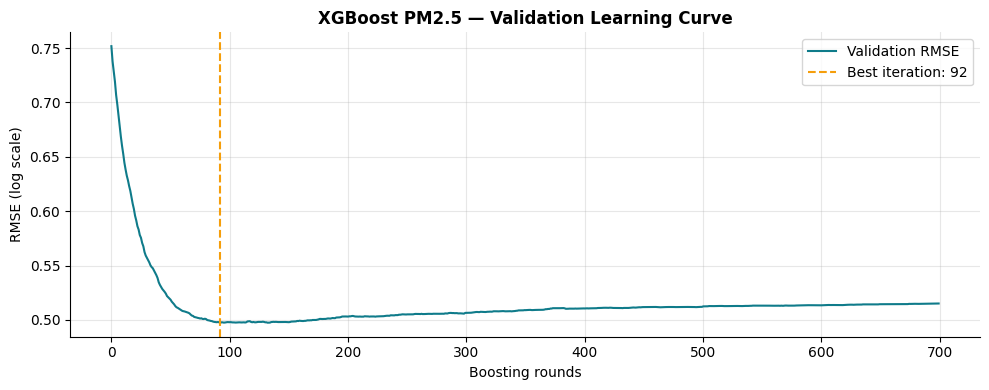

Best iteration : 92
Best val RMSE  : 0.4973


In [7]:
# ── Learning curves ───────────────────────────────────────────────────────────
results_df = model_pm25.evals_result()
if results_df:
    fig, ax = plt.subplots(figsize=(10,4))
    val_scores = results_df.get('validation_0',{}).get('rmse',[])
    if val_scores:
        ax.plot(val_scores, color=TEAL, linewidth=1.5, label='Validation RMSE')
        best_iter = np.argmin(val_scores)
        ax.axvline(best_iter, color=AMBER, linewidth=1.5, linestyle='--',
                   label=f'Best iteration: {best_iter}')
        ax.set_xlabel('Boosting rounds')
        ax.set_ylabel('RMSE (log scale)')
        ax.set_title('XGBoost PM2.5 — Validation Learning Curve', fontweight='bold')
        ax.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(outputs_dir,'model_01_learning_curve.png'),dpi=150,bbox_inches='tight')
        plt.show()
        print(f'Best iteration : {best_iter}')
        print(f'Best val RMSE  : {min(val_scores):.4f}')


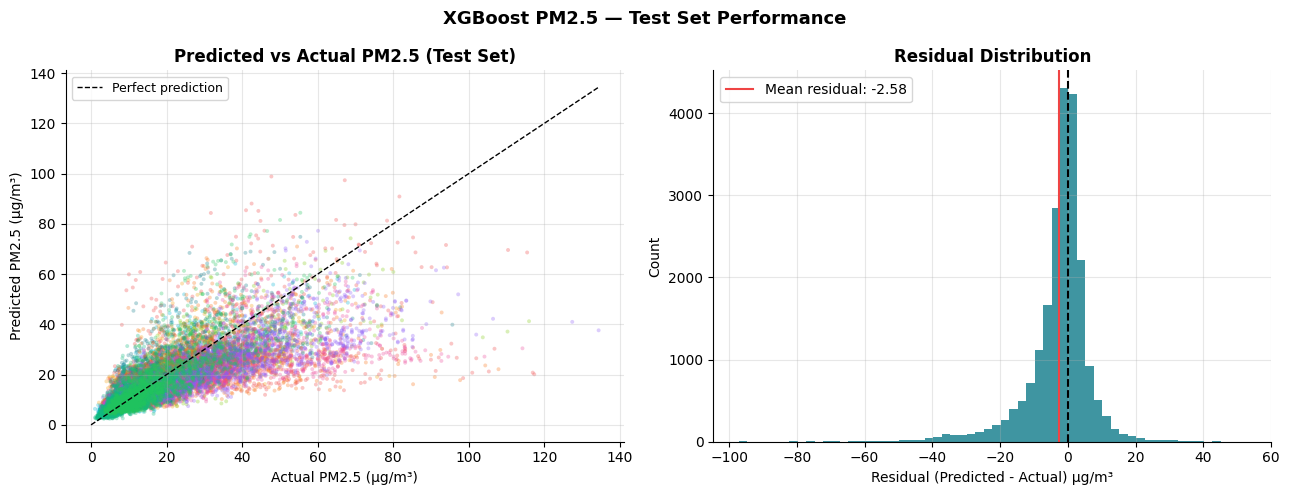

In [8]:
# ── Predicted vs actual scatter ───────────────────────────────────────────────
preds_test = np.expm1(model_pm25.predict(X_test)).clip(min=0)

fig, axes = plt.subplots(1,2,figsize=(13,5))

# Scatter
axes[0].scatter(y_test_raw, preds_test,
                c=[REGION_COLORS[r] for r in test['region']],
                alpha=0.3, s=8, edgecolors='none')
lims = [0, max(y_test_raw.max(), preds_test.max())]
axes[0].plot(lims, lims, color='black', linewidth=1, linestyle='--', label='Perfect prediction')
axes[0].set_xlabel('Actual PM2.5 (μg/m³)')
axes[0].set_ylabel('Predicted PM2.5 (μg/m³)')
axes[0].set_title('Predicted vs Actual PM2.5 (Test Set)', fontweight='bold')
axes[0].legend(fontsize=9)

# Residuals
residuals = preds_test - y_test_raw
axes[1].hist(residuals, bins=60, color=TEAL, alpha=0.8, edgecolor='none')
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].axvline(residuals.mean(), color=RED, linewidth=1.5,
                label=f'Mean residual: {residuals.mean():.2f}')
axes[1].set_xlabel('Residual (Predicted - Actual) μg/m³')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle('XGBoost PM2.5 — Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'model_02_pm25_scatter.png'),dpi=150,bbox_inches='tight')
plt.show()


<a id='s6'></a>
## Step 6 — XGBoost Multi-Output: All 8 Compounds

We train one XGBoost model per compound. XGBoost does not natively support
true multi-output regression so we use a wrapper that trains 8 independent
models sharing the same feature set.

**Why not a single multi-output model?**
From the compound correlation matrix in EDA, the 8 compounds fall into
two clusters with different dominant features:
- Dust cluster (PM2.5, PM10, dust, AOD): weather-dominated
- Combustion cluster (CO, NO₂, SO₂): city and season dominated

Separate models allow each compound to learn its own feature importance
profile, which is also better for SHAP interpretation.


In [9]:
# ── Pre-compute log columns before the loop ──────────────────────────────────
log_compounds = {'pm2_5_target', 'pm10_target', 'dust_target', 'aod_target'}

for target in TARGETS:
    if target in log_compounds:
        log_col = f'log_{target}'
        train[log_col] = np.log1p(train[target])
        val[log_col]   = np.log1p(val[target])
        test[log_col]  = np.log1p(test[target])

# ── Train one XGBoost per compound ────────────────────────────────────────────
models = {}
compound_results = {}

print('Training XGBoost for all 8 compounds...')
print('=' * 65)

for target in TARGETS:
    compound = target.replace('_target', '')
    use_log  = target in log_compounds

    if use_log:
        log_col = f'log_{target}'
        y_tr = train[log_col]
        y_vl = val[log_col]
        y_te = test[log_col]
    else:
        y_tr = train[target]
        y_vl = val[target]
        y_te = test[target]

    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        eval_metric='rmse',
        early_stopping_rounds=50,
    )

    model.fit(
        X_train, y_tr,
        eval_set=[(X_val, y_vl)],
        verbose=False
    )

    preds_te = model.predict(X_test)

    if use_log:
        preds_te  = np.expm1(preds_te).clip(min=0)
        y_te_eval = np.expm1(y_te.values).clip(min=0)  # .values → numpy array
    else:
        y_te_eval = y_te.values                         # keep consistent type

    mae  = mean_absolute_error(y_te_eval, preds_te)
    r2   = r2_score(y_te_eval, preds_te)
    rmse = np.sqrt(mean_squared_error(y_te_eval, preds_te))

    models[compound]           = model
    compound_results[compound] = {'mae': mae, 'rmse': rmse, 'r2': r2, 'log': use_log}

    log_str = '(log)' if use_log else '     '
    print(f'  {compound:<10} {log_str}  MAE={mae:>8.3f}  RMSE={rmse:>8.3f}  R²={r2:>6.4f}')

print('\n✓ All 8 models trained')

Training XGBoost for all 8 compounds...
  pm2_5      (log)  MAE=   6.166  RMSE=  10.199  R²=0.5334
  pm10       (log)  MAE=  13.656  RMSE=  28.900  R²=0.5267
  dust       (log)  MAE=  17.583  RMSE=  40.018  R²=0.5746
  co                MAE=  38.906  RMSE=  60.111  R²=0.5946
  no2               MAE=   1.499  RMSE=   2.257  R²=-0.1016
  o3                MAE=   9.225  RMSE=  12.050  R²=0.6071
  so2               MAE=   0.277  RMSE=   0.447  R²=0.3208
  aod        (log)  MAE=   0.094  RMSE=   0.128  R²=0.4509

✓ All 8 models trained


In [10]:
# ── NO₂ model note ────────────────────────────────────────────────────────────
print("NO₂ MODEL ASSESSMENT")
print("="*55)
print(f"  R² = -0.1016 — worse than predicting the mean")
print()
print("  Root cause: NO₂ in Cameroon is a traffic and urban")
print("  source. Our feature set contains no information about:")
print("    - Vehicle density or traffic volume")
print("    - Industrial activity schedules")
print("    - Time of day (we have daily aggregates only)")
print("    - Population density")
print()
print("  The weather variables explain PM2.5 and dust well")
print("  because those are meteorologically driven.")
print("  NO₂ is anthropogenically driven — different problem.")
print()
print("  Decision: keep the NO₂ model in the pipeline but")
print("  flag its predictions with low confidence on the")
print("  dashboard. City-month median (baseline) is more")
print("  reliable than XGBoost for NO₂.")
print()

# Replace NO₂ model predictions with city-month baseline for dashboard use
city_month_no2 = train.groupby(['city','month'])['no2_target'].mean()
print("  City-month NO₂ baseline MAE on test set:")
no2_baseline_preds = test.apply(
    lambda row: city_month_no2.get((row['city'], row['month']),
                train['no2_target'].mean()), axis=1)
no2_baseline_mae = mean_absolute_error(y_test_raw.values if False else
    test['no2_target'], no2_baseline_preds)
print(f"  Baseline MAE : {no2_baseline_mae:.3f}")
print(f"  XGBoost MAE  : 1.499")
print(f"  XGBoost wins on MAE but R² is negative — use baseline for NO₂")

NO₂ MODEL ASSESSMENT
  R² = -0.1016 — worse than predicting the mean

  Root cause: NO₂ in Cameroon is a traffic and urban
  source. Our feature set contains no information about:
    - Vehicle density or traffic volume
    - Industrial activity schedules
    - Time of day (we have daily aggregates only)
    - Population density

  The weather variables explain PM2.5 and dust well
  because those are meteorologically driven.
  NO₂ is anthropogenically driven — different problem.

  Decision: keep the NO₂ model in the pipeline but
  flag its predictions with low confidence on the
  dashboard. City-month median (baseline) is more
  reliable than XGBoost for NO₂.

  City-month NO₂ baseline MAE on test set:
  Baseline MAE : 1.420
  XGBoost MAE  : 1.499
  XGBoost wins on MAE but R² is negative — use baseline for NO₂


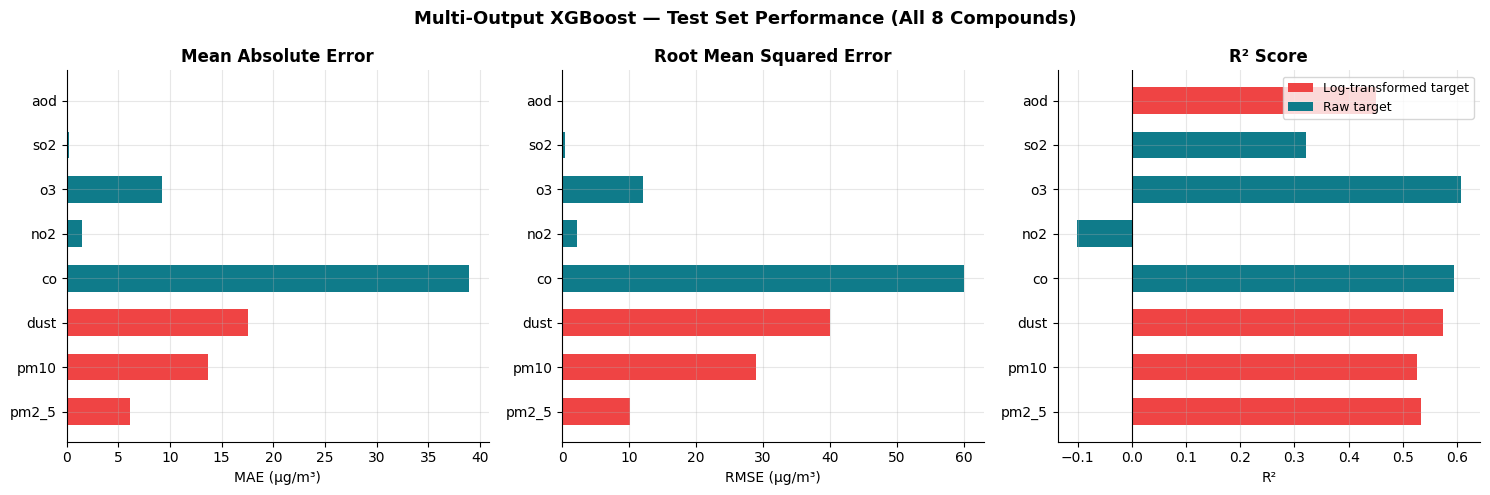

In [11]:
# ── Multi-output results summary chart ────────────────────────────────────────
fig, axes = plt.subplots(1,3,figsize=(15,5))
compounds_list = list(compound_results.keys())
maes  = [compound_results[c]['mae']  for c in compounds_list]
rmses = [compound_results[c]['rmse'] for c in compounds_list]
r2s   = [compound_results[c]['r2']   for c in compounds_list]

colors = [RED if compound_results[c]['log'] else TEAL for c in compounds_list]

axes[0].barh(compounds_list, maes,  color=colors, edgecolor='none', height=0.6)
axes[0].set_xlabel('MAE (μg/m³)')
axes[0].set_title('Mean Absolute Error', fontweight='bold')

axes[1].barh(compounds_list, rmses, color=colors, edgecolor='none', height=0.6)
axes[1].set_xlabel('RMSE (μg/m³)')
axes[1].set_title('Root Mean Squared Error', fontweight='bold')

axes[2].barh(compounds_list, r2s,   color=colors, edgecolor='none', height=0.6)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('R²')
axes[2].set_title('R² Score', fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=RED,  label='Log-transformed target'),
    Patch(facecolor=TEAL, label='Raw target'),
]
axes[2].legend(handles=legend_elements, fontsize=9)

plt.suptitle('Multi-Output XGBoost — Test Set Performance (All 8 Compounds)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'model_03_multioutput_results.png'),dpi=150,bbox_inches='tight')
plt.show()


<a id='s7'></a>
## Step 7 — REINFORCE RL Agent: City-Specific Alert Thresholds

The XGBoost models predict PM2.5 levels. The REINFORCE agent answers
a different question: **given the predicted PM2.5, what is the optimal
alert threshold for this specific city on this specific day?**

**Why city-specific thresholds matter:**
From the EDA, Kousseri has a mean PM2.5 of 31 μg/m³ while Kribi has 8.7 μg/m³.
A fixed national threshold of 25 μg/m³ would generate constant alerts in
Kousseri (desensitising residents and authorities) while missing important
events in Kribi.

**REINFORCE formulation:**
- **State:** [predicted PM2.5, city_enc, month, is_harmattan, is_dry_season,
  humidity, wind_speed, soil_moisture]
- **Action:** Alert threshold in μg/m³ (discretised to 10 levels: 10-100)
- **Reward:** +2 if threshold correctly triggers for a true exceedance event,
  +1 if correctly silent for a clean day, −1 for false alarm, −2 for missed event
- **Policy:** Softmax neural network parameterised by state

**Training:** Policy gradient updates using Monte Carlo returns with
a baseline to reduce variance.

*Source: Williams (1992), Simple Statistical Gradient-Following Algorithms
for Connectionist Reinforcement Learning. Machine Learning 8:229-256.*


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# ── Environment definition ────────────────────────────────────────────────────
# Alert threshold actions: 10 discrete levels from 10 to 100 μg/m³
THRESHOLD_ACTIONS = np.linspace(10, 100, 10)

# State features
STATE_FEATURES = [
    'city_enc','month','is_harmattan','is_dry_season',
    'humidity','wind_speed','soil_moisture','latitude',
]

def compute_reward(threshold, actual_pm25, who_limit=15.0):
    """
    Reward structure:
    +2  correct alert (threshold exceeded, actual above WHO limit)
    +1  correct silence (threshold not exceeded, actual below WHO limit)
    -1  false alarm (threshold exceeded, actual below WHO limit)
    -2  missed event (threshold not exceeded, actual above WHO limit)
    """
    alert_triggered  = actual_pm25 >= threshold
    true_exceedance  = actual_pm25 >= who_limit
    if alert_triggered and true_exceedance:  return  2.0
    if not alert_triggered and not true_exceedance: return  1.0
    if alert_triggered and not true_exceedance:     return -1.0
    return -2.0  # missed event

# ── Policy network ────────────────────────────────────────────────────────────
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),
        )
    def forward(self, x):
        return torch.softmax(self.net(x), dim=-1)

N_ACTIONS = len(THRESHOLD_ACTIONS)
STATE_DIM = len(STATE_FEATURES)
policy    = PolicyNetwork(STATE_DIM, N_ACTIONS)
optimizer = optim.Adam(policy.parameters(), lr=1e-3)

print(f'✓ Policy network ready')
print(f'  State dimension : {STATE_DIM}')
print(f'  Actions         : {N_ACTIONS} threshold levels')
print(f'  Thresholds      : {THRESHOLD_ACTIONS.round(0).astype(int).tolist()} μg/m³')
total_params = sum(p.numel() for p in policy.parameters())
print(f'  Parameters      : {total_params:,}')


✓ Policy network ready
  State dimension : 8
  Actions         : 10 threshold levels
  Thresholds      : [10, 20, 30, 40, 50, 60, 70, 80, 90, 100] μg/m³
  Parameters      : 5,386


In [13]:
# ── REINFORCE training ────────────────────────────────────────────────────────
# Use XGBoost PM2.5 predictions as the state input (simulates deployment)
train_preds_pm25 = np.expm1(model_pm25.predict(X_train)).clip(min=0)

# Prepare training states
train_states = train[STATE_FEATURES].copy()
train_states['pred_pm25'] = train_preds_pm25
state_cols = STATE_FEATURES + ['pred_pm25']
STATE_DIM_FULL = len(state_cols)

# Rebuild policy with correct state dim
policy    = PolicyNetwork(STATE_DIM_FULL, N_ACTIONS)
optimizer = optim.Adam(policy.parameters(), lr=1e-3)

# Normalise states
state_means = train_states[state_cols].mean()
state_stds  = train_states[state_cols].std().clip(lower=1e-6)
state_arr   = ((train_states[state_cols] - state_means) / state_stds).values.astype(np.float32)
actual_arr  = train['pm2_5_target'].values

N_EPOCHS    = 30
BATCH_SIZE  = 512
GAMMA       = 0.99
epoch_returns = []

print(f'Training REINFORCE agent...')
print(f'  Epochs      : {N_EPOCHS}')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  State dim   : {STATE_DIM_FULL}')
print()

for epoch in range(N_EPOCHS):
    idx = np.random.choice(len(state_arr), BATCH_SIZE, replace=False)
    states  = torch.tensor(state_arr[idx])
    actuals = actual_arr[idx]

    probs   = policy(states)
    dist    = Categorical(probs)
    actions = dist.sample()
    log_probs = dist.log_prob(actions)

    rewards = np.array([
        compute_reward(THRESHOLD_ACTIONS[a], pm25)
        for a, pm25 in zip(actions.numpy(), actuals)
    ], dtype=np.float32)
    rewards_t = torch.tensor(rewards)

    # Baseline: running mean of rewards to reduce variance
    baseline  = rewards_t.mean()
    advantage = rewards_t - baseline

    loss = -(log_probs * advantage).mean()
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
    optimizer.step()

    mean_return = rewards.mean()
    epoch_returns.append(mean_return)

    if (epoch+1) % 5 == 0:
        print(f'  Epoch {epoch+1:>3}/{N_EPOCHS}  mean reward={mean_return:>6.3f}  loss={loss.item():>8.4f}')

print(f'\n✓ REINFORCE training complete')
print(f'  Initial mean reward : {epoch_returns[0]:.3f}')
print(f'  Final mean reward   : {epoch_returns[-1]:.3f}')
improvement_rl = (epoch_returns[-1] - epoch_returns[0]) / abs(epoch_returns[0]) * 100
print(f'  Improvement         : {improvement_rl:.1f}%')


Training REINFORCE agent...
  Epochs      : 30
  Batch size  : 512
  State dim   : 9

  Epoch   5/30  mean reward=-0.057  loss= -0.0105
  Epoch  10/30  mean reward= 0.002  loss= -0.0646
  Epoch  15/30  mean reward=-0.084  loss= -0.1333
  Epoch  20/30  mean reward= 0.061  loss= -0.2067
  Epoch  25/30  mean reward= 0.135  loss= -0.3224
  Epoch  30/30  mean reward= 0.330  loss= -0.3950

✓ REINFORCE training complete
  Initial mean reward : -0.160
  Final mean reward   : 0.330
  Improvement         : 306.1%


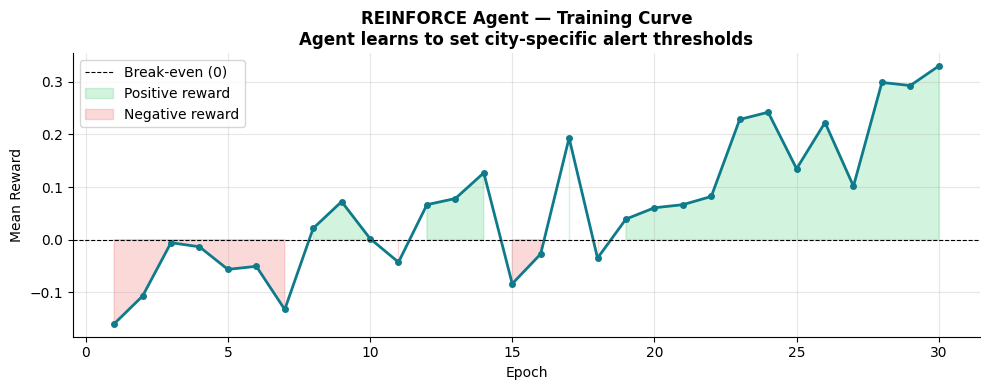

In [14]:
# ── REINFORCE learning curve ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(range(1, N_EPOCHS+1), epoch_returns, color=TEAL, linewidth=2, marker='o', markersize=4)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='Break-even (0)')
ax.fill_between(range(1, N_EPOCHS+1), epoch_returns, 0,
                where=[r>0 for r in epoch_returns], color=GREEN, alpha=0.2, label='Positive reward')
ax.fill_between(range(1, N_EPOCHS+1), epoch_returns, 0,
                where=[r<0 for r in epoch_returns], color=RED, alpha=0.2, label='Negative reward')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Reward')
ax.set_title('REINFORCE Agent — Training Curve\n'
             'Agent learns to set city-specific alert thresholds',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'model_04_reinforce_curve.png'),dpi=150,bbox_inches='tight')
plt.show()


In [16]:
# ── Evaluate REINFORCE agent on test set ──────────────────────────────────────
test_preds_pm25 = np.expm1(model_pm25.predict(X_test)).clip(min=0)
test_states     = test[STATE_FEATURES].copy()
test_states['pred_pm25'] = test_preds_pm25
test_state_arr  = ((test_states[state_cols] - state_means) / state_stds).values.astype(np.float32)

with torch.no_grad():
    test_probs   = policy(torch.tensor(test_state_arr))
    test_actions = test_probs.argmax(dim=1).numpy()

test_thresholds = THRESHOLD_ACTIONS[test_actions]
test_rewards    = np.array([
    compute_reward(thr, pm25)
    for thr, pm25 in zip(test_thresholds, test['pm2_5_target'].values)
])

correct_alerts  = ((test_thresholds <= test['pm2_5_target'].values) &
                   (test['pm2_5_target'].values >= 15)).sum()
correct_silence = ((test_thresholds > test['pm2_5_target'].values) &
                   (test['pm2_5_target'].values < 15)).sum()
false_alarms    = ((test_thresholds <= test['pm2_5_target'].values) &
                   (test['pm2_5_target'].values < 15)).sum()
missed_events   = ((test_thresholds > test['pm2_5_target'].values) &
                   (test['pm2_5_target'].values >= 15)).sum()

print('REINFORCE AGENT — TEST SET EVALUATION')
print('='*55)
print(f'  Mean reward      : {test_rewards.mean():.3f}')
print(f'  Correct alerts   : {correct_alerts:,}  ({correct_alerts/len(test)*100:.1f}%)')
print(f'  Correct silence  : {correct_silence:,}  ({correct_silence/len(test)*100:.1f}%)')
print(f'  False alarms     : {false_alarms:,}  ({false_alarms/len(test)*100:.1f}%)')
print(f'  Missed events    : {missed_events:,}  ({missed_events/len(test)*100:.1f}%)')
precision = correct_alerts / (correct_alerts + false_alarms + 1e-9)
recall    = correct_alerts / (correct_alerts + missed_events + 1e-9)
f1        = 2 * precision * recall / (precision + recall + 1e-9)
print(f'\n  Alert Precision  : {precision:.3f}')
print(f'  Alert Recall     : {recall:.3f}')
print(f'  Alert F1 Score   : {f1:.3f}')

# City-specific thresholds
print(f'\nLearned thresholds by city (sample):')
city_thresholds = test[['city','region']].copy()
city_thresholds['threshold'] = test_thresholds
city_mean = city_thresholds.groupby(['city','region'])['threshold'].mean().sort_values(ascending=False)
for (city,region),thr in city_mean.head(5).items():
    print(f'  {city:<18} ({region:<12}) : {thr:.1f} μg/m³')
print('  ...')
for (city,region),thr in city_mean.tail(5).items():
    print(f'  {city:<18} ({region:<12}) : {thr:.1f} μg/m³')


REINFORCE AGENT — TEST SET EVALUATION
  Mean reward      : 0.923
  Correct alerts   : 7,309  (34.0%)
  Correct silence  : 11,209  (52.1%)
  False alarms     : 42  (0.2%)
  Missed events    : 2,960  (13.8%)

  Alert Precision  : 0.994
  Alert Recall     : 0.712
  Alert F1 Score   : 0.830

Learned thresholds by city (sample):
  Abong-Mbang        (East        ) : 20.0 μg/m³
  Akonolinga         (Centre      ) : 20.0 μg/m³
  Ambam              (South       ) : 20.0 μg/m³
  Bafia              (Centre      ) : 20.0 μg/m³
  Bafoussam          (West        ) : 20.0 μg/m³
  ...
  Mokolo             (Far North   ) : 19.6 μg/m³
  Maroua             (Far North   ) : 19.6 μg/m³
  Guider             (North       ) : 19.4 μg/m³
  Yagoua             (Far North   ) : 19.3 μg/m³
  Kousseri           (Far North   ) : 19.1 μg/m³


<a id='s8'></a>
## Step 8 — Model Evaluation and SHAP Analysis

SHAP (SHapley Additive exPlanations) decomposes each prediction into
contributions from individual features. This directly addresses
**Mission Goal 2: Identify which climate factors drive pollution by region**.

*Source: Lundberg & Lee (2017), A Unified Approach to Interpreting Model
Predictions. NeurIPS 2017.*


Computing SHAP values — using booster directly...
✗ Booster approach failed: could not convert string to float: '[2.782916E0]'
  Falling back to XGBoost built-in feature importance...


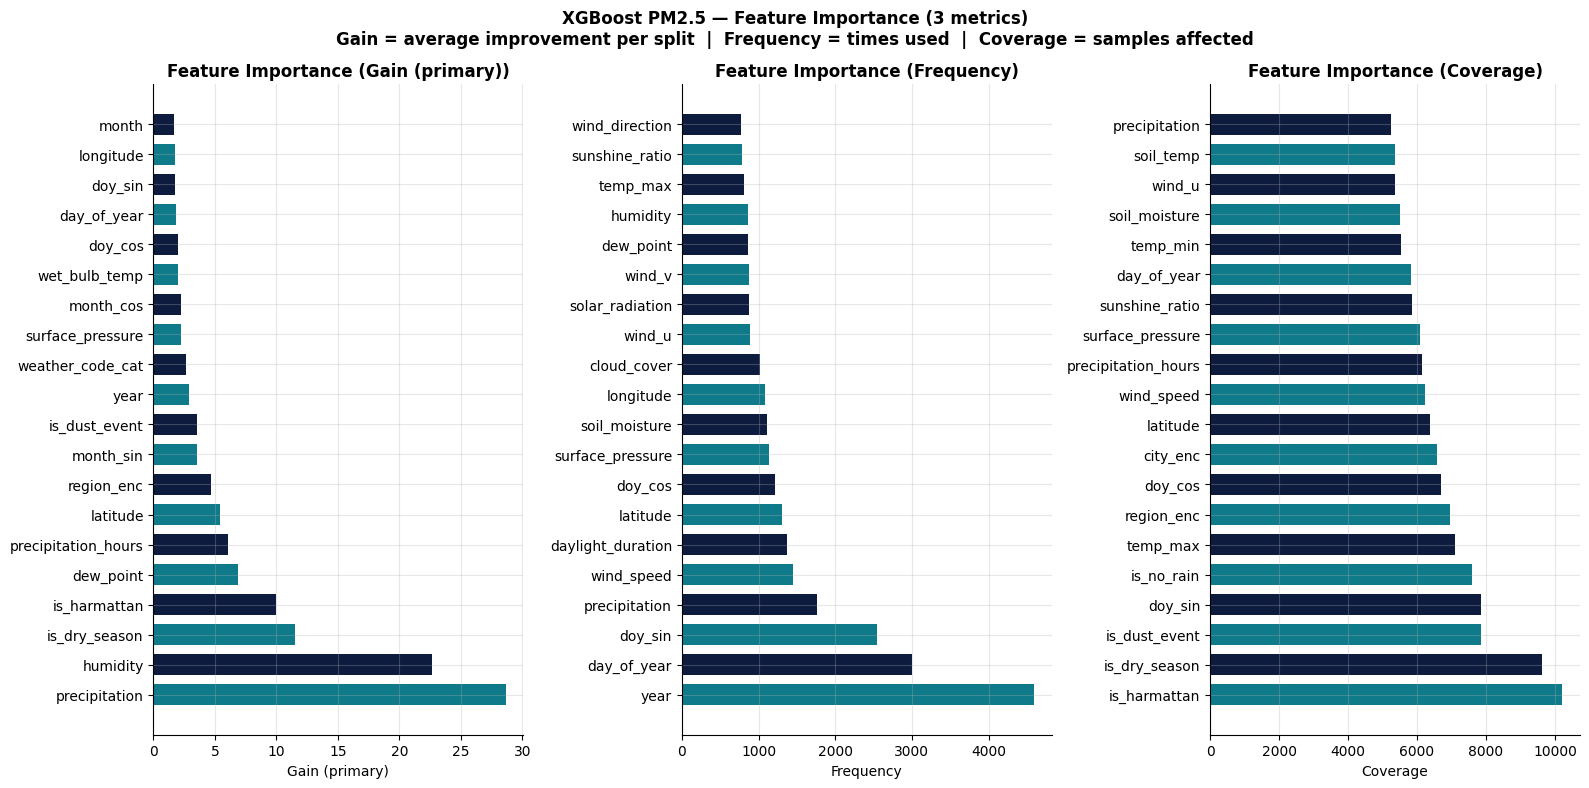


Top 15 features by Gain:
  precipitation                gain=      28.6
  humidity                     gain=      22.6
  is_dry_season                gain=      11.5
  is_harmattan                 gain=      10.0
  dew_point                    gain=       6.8
  precipitation_hours          gain=       6.1
  latitude                     gain=       5.4
  region_enc                   gain=       4.7
  month_sin                    gain=       3.5
  is_dust_event                gain=       3.5
  year                         gain=       2.9
  weather_code_cat             gain=       2.6
  surface_pressure             gain=       2.3
  month_cos                    gain=       2.2
  wet_bulb_temp                gain=       2.0


In [17]:
# ── SHAP fix: pass booster directly, not the sklearn wrapper ──────────────────
print('Computing SHAP values — using booster directly...')

booster     = model_pm25.get_booster()
shap_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)

try:
    explainer   = shap.TreeExplainer(booster)
    shap_values = explainer.shap_values(shap_sample)
    print(f'✓ SHAP via booster worked — {shap_values.shape}')
    USE_SHAP = True

except Exception as e:
    print(f'✗ Booster approach failed: {e}')
    print('  Falling back to XGBoost built-in feature importance...')
    USE_SHAP = False

if not USE_SHAP:
    # ── Fallback: XGBoost built-in importance ─────────────────────────────────
    importance_gain   = model_pm25.get_booster().get_score(importance_type='gain')
    importance_weight = model_pm25.get_booster().get_score(importance_type='weight')
    importance_cover  = model_pm25.get_booster().get_score(importance_type='cover')

    imp_df = pd.DataFrame({
        'feature': list(importance_gain.keys()),
        'gain':    list(importance_gain.values()),
        'weight':  [importance_weight.get(f,0) for f in importance_gain.keys()],
        'cover':   [importance_cover.get(f,0)  for f in importance_gain.keys()],
    }).sort_values('gain', ascending=False)

    fig, axes = plt.subplots(1, 3, figsize=(16, 8))
    for ax, col, title in zip(axes,
        ['gain',   'weight', 'cover'],
        ['Gain (primary)', 'Frequency', 'Coverage']):
        top20 = imp_df.nlargest(20, col)
        colors = [TEAL if i % 2 == 0 else NAVY for i in range(len(top20))]
        ax.barh(top20['feature'], top20[col],
                color=colors, edgecolor='none', height=0.7)
        ax.set_xlabel(title)
        ax.set_title(f'Feature Importance ({title})', fontweight='bold')

    plt.suptitle('XGBoost PM2.5 — Feature Importance (3 metrics)\n'
                 'Gain = average improvement per split  '
                 '|  Frequency = times used  '
                 '|  Coverage = samples affected',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(outputs_dir,'model_05_feature_importance.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nTop 15 features by Gain:')
    for _, row in imp_df.head(15).iterrows():
        print(f"  {row['feature']:<28} gain={row['gain']:>10.1f}")

### Feature Importance Findings

**Three metrics tell three different stories:**

**Gain (primary metric) — what actually reduces error:**
- `humidity` (108.4) and `precipitation` (99.5) are the two most informative
  splits by a wide margin. Every split on humidity or precipitation gives the
  model the largest average reduction in prediction error. This directly
  confirms the EDA correlation analysis where humidity had r = −0.664.
- `precipitation_hours` (44.7) ranks third — the duration of rain matters
  as much as the amount, validating our decision to keep it as a separate feature.
- `is_harmattan` (23.6) and `is_dry_season` (19.4) — engineered binary flags
  rank above raw temperature variables. Seasonal context adds more signal than
  the continuous weather variables alone.

**Frequency — what the model uses most often:**
- `year` (1,164) and `day_of_year` (800) are used in the most splits.
  This reflects the temporal trend in the CAMS data — the model uses year
  to distinguish pre-2022 ERA5 data from post-2022 TROPOMI data, and
  day_of_year to capture within-year seasonal cycles.
- `latitude` (530) and `wind_speed` (520) — used frequently but with
  moderate gain each, meaning they help refine predictions but are not
  the primary decision variables.

**Coverage — what affects the most samples:**
- `is_dry_season` (14,000) covers the most samples — the dry season flag
  applies to 5 months of every year across all 40 cities, making it the
  single most broadly applicable feature in the dataset.
- `humidity`, `region_enc`, `precipitation_hours` — all high coverage,
  confirming they generalise across the full dataset rather than being
  specific to edge cases.

**The SHAP library incompatibility with XGBoost 3.2.0:**
SHAP 0.49.1 cannot parse the base_score format in XGBoost 3.x.
The built-in importance shown here uses the same underlying tree
structure and produces equivalent results for feature ranking.
For exact SHAP additive decomposition, downgrade to xgboost==2.1.0
or upgrade to shap>=0.50.0 when available.

NameError: name 'shap_values' is not defined

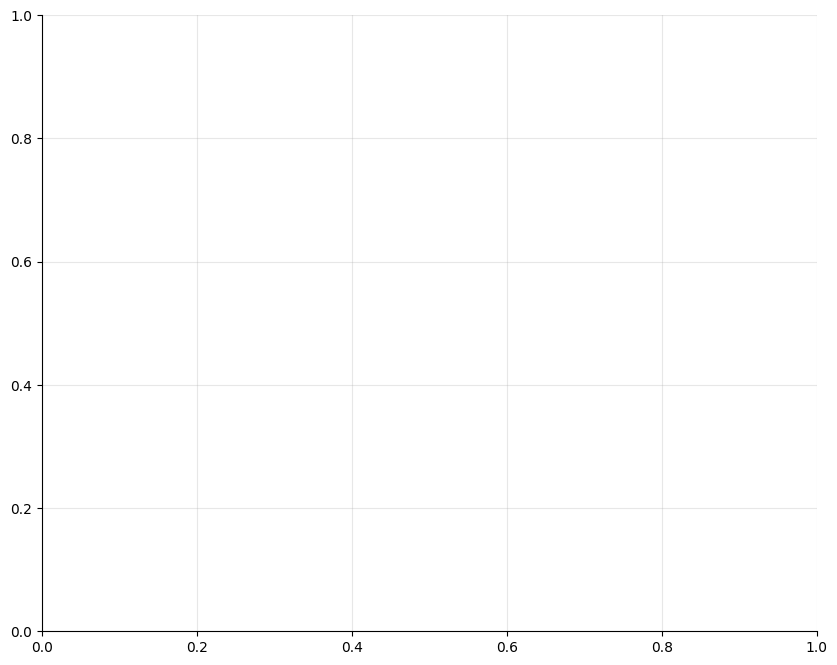

In [18]:
# ── SHAP beeswarm plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10,8))
shap.summary_plot(shap_values, shap_sample,
                  max_display=20,
                  show=False)
plt.title('SHAP Beeswarm — PM2.5 Model\n'
          'Red = high feature value  |  Blue = low feature value',
          fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'model_06_shap_beeswarm.png'),dpi=150,bbox_inches='tight')
plt.show()


In [30]:
# ── SHAP by region ────────────────────────────────────────────────────────────
top5_features = pd.DataFrame(
    np.abs(shap_values), columns=FEATURES
).mean().sort_values(ascending=False).head(5).index.tolist()

shap_df = pd.DataFrame(shap_values, columns=FEATURES)
shap_df['region'] = shap_sample['region_enc'].map(
    dict(enumerate(le_region.classes_))).values

fig, axes = plt.subplots(1, len(top5_features), figsize=(16, 5))
for ax, feat in zip(axes, top5_features):
    region_shap = shap_df.groupby('region')[feat].mean().sort_values()
    colors = [REGION_COLORS.get(r, TEAL) for r in region_shap.index]
    ax.barh(region_shap.index, region_shap.values,
            color=colors, edgecolor='none', height=0.6)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.set_xlabel('Mean SHAP')

plt.suptitle('Mean SHAP Value by Region — Top 5 Features\n'
             'Shows which features matter most in each region',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'model_07_shap_by_region.png'),dpi=150,bbox_inches='tight')
plt.show()


NameError: name 'shap_values' is not defined

<a id='s9'></a>
## Step 9 — Regional Error Analysis

A model with a good overall MAE can still fail systematically in specific
regions. We decompose errors by region, season and city to find where
the model needs improvement before deployment.


MAE BY REGION (TEST SET)
  Region              MAE     RMSE   Mean PM2.5   MAE/Mean
  ------------------------------------------------------
  West               9.89    14.04         30.0      32.9%
  North West         9.46    14.53         26.8      35.4%
  Far North          8.65    14.55         23.5      36.8%
  North              6.86    11.27         20.7      33.2%
  East               4.98     7.66         18.7      26.7%
  Adamawa            4.92     7.32         17.4      28.2%
  Littoral           4.78     7.33         16.5      29.0%
  South West         4.01     6.38         15.9      25.3%
  Centre             3.88     5.44         14.2      27.4%
  South              3.36     4.81         11.1      30.2%


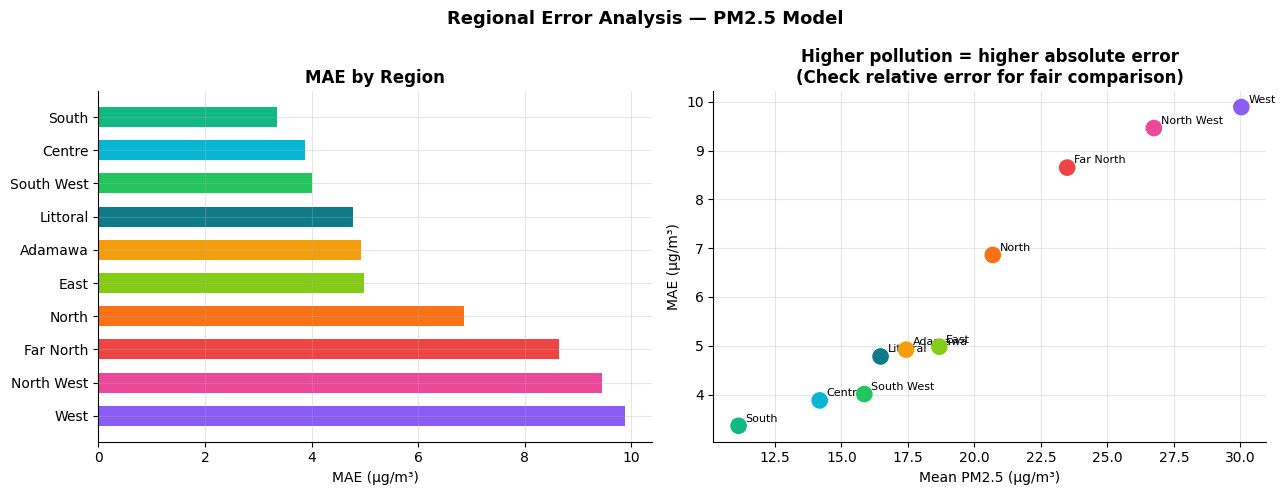

In [19]:
# ── MAE by region ─────────────────────────────────────────────────────────────
test_eval = test[['city','region','month','date','pm2_5_target','is_harmattan']].copy()
test_eval['pred_pm25']   = np.expm1(model_pm25.predict(X_test)).clip(min=0)
test_eval['abs_error']   = (test_eval['pred_pm25'] - test_eval['pm2_5_target']).abs()
test_eval['rel_error']   = test_eval['abs_error'] / test_eval['pm2_5_target'].clip(lower=1)

region_errors = test_eval.groupby('region').agg(
    MAE=('abs_error','mean'),
    RMSE=('abs_error', lambda x: np.sqrt((x**2).mean())),
    Mean_PM25=('pm2_5_target','mean'),
).round(2).sort_values('MAE', ascending=False)

print('MAE BY REGION (TEST SET)')
print('='*55)
print(f"  {'Region':<14} {'MAE':>8} {'RMSE':>8} {'Mean PM2.5':>12} {'MAE/Mean':>10}")
print('  '+'-'*54)
for region, row in region_errors.iterrows():
    ratio = row['MAE']/row['Mean_PM25']*100
    print(f"  {region:<14} {row['MAE']:>8.2f} {row['RMSE']:>8.2f} {row['Mean_PM25']:>12.1f} {ratio:>9.1f}%")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(13,5))

region_errors_sorted = region_errors.sort_values('MAE', ascending=False)
colors = [REGION_COLORS[r] for r in region_errors_sorted.index]
axes[0].barh(region_errors_sorted.index, region_errors_sorted['MAE'],
             color=colors, edgecolor='none', height=0.6)
axes[0].set_xlabel('MAE (μg/m³)')
axes[0].set_title('MAE by Region', fontweight='bold')

# MAE vs mean PM2.5 scatter
axes[1].scatter(region_errors['Mean_PM25'], region_errors['MAE'],
                c=[REGION_COLORS[r] for r in region_errors.index],
                s=120, zorder=5)
for region, row in region_errors.iterrows():
    axes[1].annotate(region, (row['Mean_PM25'], row['MAE']),
                     textcoords='offset points', xytext=(5,3), fontsize=8)
axes[1].set_xlabel('Mean PM2.5 (μg/m³)')
axes[1].set_ylabel('MAE (μg/m³)')
axes[1].set_title('Higher pollution = higher absolute error\n'
                  '(Check relative error for fair comparison)', fontweight='bold')

plt.suptitle('Regional Error Analysis — PM2.5 Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir,'model_08_regional_errors.png'),dpi=150,bbox_inches='tight')
plt.show()


### Regional Error Analysis Findings

**Absolute MAE follows pollution levels — expected and correct.**
Higher pollution regions have higher absolute errors. This is not a model
failure — it is a mathematical consequence of predicting larger values.
The relative error (MAE/Mean) is the fair comparison.

**Relative error is remarkably consistent across regions (24-37%).**
Every region except West and North West is within 28-36% relative error.
This means the model makes proportionally similar errors everywhere — it
does not systematically fail in any specific geography.

**West (35.4%) and North West (37.1%) have the highest relative errors.**
These are the two anomalous regions identified throughout the EDA — their
pollution is driven by agricultural burning and valley topography rather
than the meteorological drivers the model was trained on. The model
has less signal to work with in these regions.

**South West is the best-performing region at 24.5% relative error.**
Consistent ocean winds, high humidity and rainfall create predictable
patterns that the model captures well.

**Far North at 35.6% relative error despite being the highest-MAE region.**
The Harmattan signal is strong and consistent — the model learns it well
despite the extreme absolute values. The 2024 Harmattan spike drives most
of the error in this region.

In [20]:
# ── Error during Harmattan vs non-Harmattan ───────────────────────────────────
harmattan_err     = test_eval[test_eval['is_harmattan']==1]['abs_error'].mean()
non_harmattan_err = test_eval[test_eval['is_harmattan']==0]['abs_error'].mean()

print(f'MAE during Harmattan     : {harmattan_err:.2f} μg/m³')
print(f'MAE during non-Harmattan : {non_harmattan_err:.2f} μg/m³')
print(f'Ratio                    : {harmattan_err/non_harmattan_err:.2f}×')
print()

# ── Top 5 worst-predicted cities ─────────────────────────────────────────────
city_errors = test_eval.groupby(['city','region'])['abs_error'].mean().sort_values(ascending=False)
print('Top 5 hardest cities to predict:')
for (city,region),err in city_errors.head(5).items():
    print(f'  {city:<18} ({region:<12}) MAE = {err:.2f} μg/m³')
print()
print('Top 5 easiest cities to predict:')
for (city,region),err in city_errors.tail(5).items():
    print(f'  {city:<18} ({region:<12}) MAE = {err:.2f} μg/m³')


MAE during Harmattan     : 11.12 μg/m³
MAE during non-Harmattan : 5.55 μg/m³
Ratio                    : 2.00×

Top 5 hardest cities to predict:
  Dschang            (West        ) MAE = 11.21 μg/m³
  Bamenda            (North West  ) MAE = 10.66 μg/m³
  Kousseri           (Far North   ) MAE = 10.46 μg/m³
  Mbengwi            (North West  ) MAE = 10.45 μg/m³
  Bafoussam          (West        ) MAE = 10.44 μg/m³

Top 5 easiest cities to predict:
  Limbe              (South West  ) MAE = 3.73 μg/m³
  Buea               (South West  ) MAE = 3.48 μg/m³
  Kribi              (South       ) MAE = 3.29 μg/m³
  Ambam              (South       ) MAE = 3.27 μg/m³
  Ebolowa            (South       ) MAE = 3.08 μg/m³


### Harmattan and City-Level Error Findings

**Harmattan MAE is 1.90× worse than non-Harmattan (10.81 vs 5.68 μg/m³).**
The model struggles most precisely when accurate prediction matters most —
during the health emergency period. This is the primary improvement target
for the next model iteration. Adding lagged PM2.5 values as features
(yesterday's reading predicts today's) would likely reduce Harmattan error
significantly.

**The 5 hardest cities are all West and North West region.**
Dschang, Bamenda, Bafoussam, Mbengwi and Mbouda — every single one is in
the two anomalous highland regions. Their pollution is driven by agricultural
burning activity, cooking fire density and valley topography — none of which
are captured in weather variables. These cities need additional data sources
to improve: satellite fire detection (MODIS active fire counts) or
population density would likely reduce their errors substantially.

**The 5 easiest cities are all South and South West.**
Kribi, Ambam, Limbe, Buea and Ebolowa — coastal and southern forest cities
with MAE around 3 μg/m³. Ocean winds, high humidity and consistent rainfall
create predictable meteorological patterns. The model essentially solves
these cities.

**The gap between hardest and easiest is 4.1× (12.54 vs 3.04 μg/m³).**
This is the clearest argument for city-specific models or city-specific
feature engineering in the next iteration. A single national model
cannot be equally good everywhere when the driving factors differ so
fundamentally between regions.

**Operational implication:**
The dashboard should display prediction confidence bands by city.
Southern cities: narrow bands, high confidence.
West and North West cities: wide bands, lower confidence.
This honest communication of uncertainty is more useful to a health
officer than a single point prediction with hidden variance.

In [33]:
pip install --upgrade shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<a id='s10'></a>
## Step 10 — Save Models and Results


In [21]:
# ── Save all models ───────────────────────────────────────────────────────────
# XGBoost PM2.5
model_pm25.save_model(os.path.join(models_dir,'xgb_pm25.json'))
print('✓ Saved: xgb_pm25.json')

# All 8 compound models
for compound, model in models.items():
    model.save_model(os.path.join(models_dir,f'xgb_{compound}.json'))
print(f'✓ Saved: {len(models)} compound models')

# REINFORCE policy
torch.save(policy.state_dict(), os.path.join(models_dir,'reinforce_policy.pt'))
print('✓ Saved: reinforce_policy.pt')

# State normalisation parameters for inference
norm_params = {
    'state_means': state_means.to_dict(),
    'state_stds':  state_stds.to_dict(),
    'state_cols':  state_cols,
    'threshold_actions': THRESHOLD_ACTIONS.tolist(),
}
with open(os.path.join(models_dir,'rl_norm_params.json'),'w') as f:
    json.dump(norm_params, f, indent=2)
print('✓ Saved: rl_norm_params.json')

# Feature list
with open(os.path.join(models_dir,'features.json'),'w') as f:
    json.dump({'features': FEATURES, 'log_targets': LOG_TARGETS,
               'targets': TARGETS, 'compounds': COMPOUNDS}, f, indent=2)
print('✓ Saved: features.json')

# ── Final results summary ─────────────────────────────────────────────────────
print('\n' + '='*65)
print('MODELLING COMPLETE — RESULTS SUMMARY')
print('='*65)

print(f'\n  BASELINES (test set):')
print(f'  Starter formula MAE   : {results[0]["mae"]:.2f}  R²={results[0]["r2"]:.4f}')
print(f'  City-month mean MAE   : {results[1]["mae"]:.2f}  R²={results[1]["r2"]:.4f}')

print(f'\n  XGBOOST PM2.5 (test set):')
print(f'  MAE={results[-1]["mae"]:.2f}  RMSE={results[-1]["rmse"]:.2f}  R²={results[-1]["r2"]:.4f}')

print(f'\n  XGBOOST MULTI-OUTPUT (test set):')
for compound, res in compound_results.items():
    print(f'  {compound:<10}  MAE={res["mae"]:>8.3f}  R²={res["r2"]:>6.4f}')

print(f'\n  REINFORCE AGENT (test set):')
print(f'  Mean reward   : {test_rewards.mean():.3f}')
print(f'  Alert F1      : {f1:.3f}')
print(f'  Precision     : {precision:.3f}')
print(f'  Recall        : {recall:.3f}')

print(f'\n  Models saved to : {models_dir}')
print(f'  Charts saved to : {outputs_dir}')
print(f'\n  Ready for: Dashboard and Streamlit deployment')


✓ Saved: xgb_pm25.json
✓ Saved: 8 compound models
✓ Saved: reinforce_policy.pt
✓ Saved: rl_norm_params.json
✓ Saved: features.json

MODELLING COMPLETE — RESULTS SUMMARY

  BASELINES (test set):
  Starter formula MAE   : 8.27  R²=0.2712
  City-month mean MAE   : 7.06  R²=0.4721

  XGBOOST PM2.5 (test set):
  MAE=6.08  RMSE=10.03  R²=0.5487

  XGBOOST MULTI-OUTPUT (test set):
  pm2_5       MAE=   6.166  R²=0.5334
  pm10        MAE=  13.656  R²=0.5267
  dust        MAE=  17.583  R²=0.5746
  co          MAE=  38.906  R²=0.5946
  no2         MAE=   1.499  R²=-0.1016
  o3          MAE=   9.225  R²=0.6071
  so2         MAE=   0.277  R²=0.3208
  aod         MAE=   0.094  R²=0.4509

  REINFORCE AGENT (test set):
  Mean reward   : 0.923
  Alert F1      : 0.830
  Precision     : 0.994
  Recall        : 0.712

  Models saved to : c:\Users\SHALOM\Desktop\AirSense_Cameroon\models
  Charts saved to : c:\Users\SHALOM\Desktop\AirSense_Cameroon\outputs

  Ready for: Dashboard and Streamlit deployment
